# Feature Group Contributions test


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v3'
RUN_DIR.mkdir(parents=True, exist_ok=True)
print('Run dir:', RUN_DIR)

Mounted at /content/drive
Run dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3


In [2]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


## 2 · Load and merge data

In [3]:
real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

LEAKAGE = ['budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
           'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_mov = real_mov.drop(columns=LEAKAGE, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE, errors='ignore')

META_KEEP = ['movie_id', 'targeted_emotion', 'clip_duration_s',
             'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
             'silence_ratio', 'music_presence', 'dialogue_density',
             'face_screen_time_ratio', 'lead_screen_time_ratio',
             'release_year', 'genre_primary', 'genre_secondary',
             'country_of_origin', 'budget_categorical',
             'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]
real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left'); real_mov['is_synthetic']=0
syn_mov  = syn_mov.merge(syn_meta_sub, on='movie_id', how='left');  syn_mov['is_synthetic']=1
df_all = pd.concat([real_mov, syn_mov], ignore_index=True)

# Encode metadata
DROP = {'movie_id','condition','n_participants',
        'imdb_rating','wom_multiplier','wom_multiplier_log','is_synthetic'}
df_feat = df_all.copy()
ORD = {'low':1,'moderate':2,'high':3}
SCENE_ORDINAL = ['cut_count','brightness','motion_intensity','audio_loudness',
                 'silence_ratio','music_presence','dialogue_density',
                 'face_screen_time_ratio','lead_screen_time_ratio']
for c in SCENE_ORDINAL + ['budget_categorical']:
    if c in df_feat.columns: df_feat[c] = df_feat[c].map(ORD)
OH = [c for c in ['targeted_emotion','genre_primary','genre_secondary','country_of_origin']
      if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH, prefix_sep='_', dummy_na=False, dtype=int)

ALL_FEATS = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[ALL_FEATS].apply(pd.to_numeric, errors='coerce')
X_all = X_all.drop(columns=X_all.columns[X_all.isna().all()].tolist())
X_all = X_all.drop(columns=X_all.columns[X_all.std()==0].tolist())
y_imdb = df_feat['imdb_rating'].astype(float)
y_wom  = df_feat['wom_multiplier_log'].astype(float)
print(f'Combined: {len(df_all)} movies × {X_all.shape[1]} features')

Combined: 50 movies × 360 features


# Define feature groups

In [4]:
# Categorise every feature column
def classify(c):
    # Self-report
    if c.startswith('sr_'): return 'self_report'
    # Physiological (note: has_* are also physiology-related quality flags)
    if c.startswith('of_') or c.startswith('q_') or c.startswith('emp_') \
        or c.startswith('eeg_') or c.startswith('sw_') or c.startswith('has_'):
        return 'physiology'
    # Scene properties (ordinal-encoded)
    if c in SCENE_ORDINAL:
        return 'scene'
    # Movie metadata: ordinal budget, year, duration
    if c in ('budget_categorical', 'release_year', 'clip_duration_s'):
        return 'metadata'
    # One-hot encoded metadata columns
    if any(c.startswith(p + '_') for p in
           ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']):
        return 'metadata'
    return 'other'

groups = {}
for c in X_all.columns:
    g = classify(c)
    groups.setdefault(g, []).append(c)

print('Feature group sizes:')
for g, cols in sorted(groups.items()):
    print(f'  {g:14s}  {len(cols):4d} features')
print(f'  {"TOTAL":14s}  {sum(len(v) for v in groups.values()):4d}')

Feature group sizes:
  metadata          31 features
  other             20 features
  physiology       258 features
  scene              9 features
  self_report       42 features
  TOTAL            360


In [5]:
CONFIGS = {
    '1. Physiology only':
        groups.get('physiology', []),
    '2. + Scene':
        groups.get('physiology', []) + groups.get('scene', []),
    '3. + Movie metadata':
        groups.get('physiology', []) + groups.get('scene', []) +
        groups.get('metadata', []),
    '4. + Self-report (current)':
        groups.get('physiology', []) + groups.get('scene', []) +
        groups.get('metadata', []) + groups.get('self_report', []),
}

print('Ablation configurations:')
for name, cols in CONFIGS.items():
    print(f'  {name:32s}  {len(cols):4d} features')

Ablation configurations:
  1. Physiology only                 258 features
  2. + Scene                         267 features
  3. + Movie metadata                298 features
  4. + Self-report (current)         340 features


# 4 configs × 2 models × 2 targets = 16 cells

In [6]:
def evaluate(X, y, model_factory, name=''):
    """5-fold CV with hyperparameter tuning. Returns metrics dict."""
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    pipe = model_factory()
    y_pred = cross_val_predict(pipe, X, y, cv=kf, n_jobs=-1)
    return {
        'r2':       r2_score(y, y_pred),
        'mae':      mean_absolute_error(y, y_pred),
        'rmse':     np.sqrt(mean_squared_error(y, y_pred)),
        'spearman': spearmanr(y, y_pred).correlation,
        'pearson':  pearsonr(y, y_pred)[0],
        'n_features': X.shape[1],
    }

def make_rf():
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('m',   RandomForestRegressor(n_estimators=500, max_depth=7,
                                       max_features=0.3, min_samples_leaf=1,
                                       random_state=42, n_jobs=-1)),
    ])

def make_pls(n_components=2):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   PLSRegression(n_components=n_components, scale=False)),
    ])

# Run with both default-tuned models on each config
results = {}
for cfg_name, cols in CONFIGS.items():
    if not cols:
        print(f'  Skipping {cfg_name} (0 features)')
        continue
    X_cfg = X_all[cols]
    results[cfg_name] = {}
    for tgt_name, y in [('imdb', y_imdb), ('wom', y_wom)]:
        for mdl_name, factory in [('RF', make_rf), ('PLS', make_pls)]:
            m = evaluate(X_cfg, y, factory, f'{cfg_name} / {tgt_name} / {mdl_name}')
            results[cfg_name][f'{mdl_name}_{tgt_name}'] = m
            print(f'  {cfg_name:32s}  {mdl_name}/{tgt_name}: '
                  f'R²={m["r2"]:>+.3f}  ρ={m["spearman"]:>+.3f}  MAE={m["mae"]:.3f}  '
                  f'(p={m["n_features"]})')

  1. Physiology only                RF/imdb: R²=+0.479  ρ=+0.706  MAE=0.324  (p=258)
  1. Physiology only                PLS/imdb: R²=+0.485  ρ=+0.703  MAE=0.316  (p=258)
  1. Physiology only                RF/wom: R²=+0.181  ρ=+0.401  MAE=0.398  (p=258)
  1. Physiology only                PLS/wom: R²=+0.002  ρ=+0.287  MAE=0.439  (p=258)
  2. + Scene                        RF/imdb: R²=+0.486  ρ=+0.699  MAE=0.326  (p=267)
  2. + Scene                        PLS/imdb: R²=+0.479  ρ=+0.697  MAE=0.324  (p=267)
  2. + Scene                        RF/wom: R²=+0.188  ρ=+0.418  MAE=0.397  (p=267)
  2. + Scene                        PLS/wom: R²=-0.013  ρ=+0.285  MAE=0.442  (p=267)
  3. + Movie metadata               RF/imdb: R²=+0.475  ρ=+0.685  MAE=0.327  (p=298)
  3. + Movie metadata               PLS/imdb: R²=+0.544  ρ=+0.739  MAE=0.296  (p=298)
  3. + Movie metadata               RF/wom: R²=+0.211  ρ=+0.441  MAE=0.392  (p=298)
  3. + Movie metadata               PLS/wom: R²=+0.022  ρ=+0.296 

# Tune PLS n_components for each config

In [ ]:

print('Tuning PLS n_components per configuration:')
for cfg_name, cols in CONFIGS.items():
    if not cols: continue
    X_cfg = X_all[cols]
    pls_grid = {'m__n_components': list(range(1, min(11, X_cfg.shape[1])))}
    for tgt_name, y in [('imdb', y_imdb), ('wom', y_wom)]:
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        search = GridSearchCV(make_pls(), pls_grid, cv=kf,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
        search.fit(X_cfg, y)
        best_n = search.best_params_['m__n_components']
        # Re-evaluate with the best n_components via cross_val_predict
        pipe = make_pls(n_components=best_n)
        y_pred = cross_val_predict(pipe, X_cfg, y, cv=kf, n_jobs=-1)
        m = {
            'r2':       r2_score(y, y_pred),
            'mae':      mean_absolute_error(y, y_pred),
            'rmse':     np.sqrt(mean_squared_error(y, y_pred)),
            'spearman': spearmanr(y, y_pred).correlation,
            'pearson':  pearsonr(y, y_pred)[0],
            'n_features': X_cfg.shape[1],
            'best_n_components': best_n,
        }
        results[cfg_name][f'PLS_{tgt_name}_tuned'] = m
        print(f'  {cfg_name:32s}  PLS-tuned/{tgt_name}: '
              f'R²={m["r2"]:>+.3f}  ρ={m["spearman"]:>+.3f}  '
              f'(n_components={best_n})')

Tuning PLS n_components per configuration:
  1. Physiology only                PLS-tuned/imdb: R²=+0.485  ρ=+0.703  (n_components=2)
  1. Physiology only                PLS-tuned/wom: R²=+0.184  ρ=+0.400  (n_components=1)
  2. + Scene                        PLS-tuned/imdb: R²=+0.479  ρ=+0.697  (n_components=2)
  2. + Scene                        PLS-tuned/wom: R²=+0.182  ρ=+0.397  (n_components=1)
  3. + Movie metadata               PLS-tuned/imdb: R²=+0.544  ρ=+0.739  (n_components=2)
  3. + Movie metadata               PLS-tuned/wom: R²=+0.098  ρ=+0.390  (n_components=10)
  4. + Self-report (current)        PLS-tuned/imdb: R²=+0.463  ρ=+0.668  (n_components=2)
  4. + Self-report (current)        PLS-tuned/wom: R²=+0.189  ρ=+0.379  (n_components=1)


# Comparison tables

In [8]:
# Table 1: R² by config × model (IMDb)
table_r2_imdb = pd.DataFrame({
    cfg: {
        'RF':        results[cfg]['RF_imdb']['r2'],
        'PLS (n=2)': results[cfg]['PLS_imdb']['r2'],
        'PLS tuned': results[cfg]['PLS_imdb_tuned']['r2'],
    } for cfg in results
}).T
print('IMDb prediction — R² by configuration × model:')
display(table_r2_imdb.round(3))

# Table 2: R² by config × model (WOM)
table_r2_wom = pd.DataFrame({
    cfg: {
        'RF':        results[cfg]['RF_wom']['r2'],
        'PLS (n=2)': results[cfg]['PLS_wom']['r2'],
        'PLS tuned': results[cfg]['PLS_wom_tuned']['r2'],
    } for cfg in results
}).T
print('\nWOM prediction — R² by configuration × model:')
display(table_r2_wom.round(3))

# Table 3: Spearman by config × model
table_spearman_imdb = pd.DataFrame({
    cfg: {
        'RF':        results[cfg]['RF_imdb']['spearman'],
        'PLS (n=2)': results[cfg]['PLS_imdb']['spearman'],
        'PLS tuned': results[cfg]['PLS_imdb_tuned']['spearman'],
    } for cfg in results
}).T
print('\nIMDb prediction — Spearman ρ by configuration × model:')
display(table_spearman_imdb.round(3))

IMDb prediction — R² by configuration × model:


,RF,PLS (n=2),PLS tuned
1. Physiology only,0.479,0.485,0.485
2. + Scene,0.486,0.479,0.479
3. + Movie metadata,0.475,0.544,0.544
4. + Self-report (current),0.543,0.463,0.463



WOM prediction — R² by configuration × model:


,RF,PLS (n=2),PLS tuned
1. Physiology only,0.181,0.002,0.184
2. + Scene,0.188,-0.013,0.182
3. + Movie metadata,0.211,0.022,0.098
4. + Self-report (current),0.201,-0.016,0.189



IMDb prediction — Spearman ρ by configuration × model:


,RF,PLS (n=2),PLS tuned
1. Physiology only,0.706,0.703,0.703
2. + Scene,0.699,0.697,0.697
3. + Movie metadata,0.685,0.739,0.739
4. + Self-report (current),0.677,0.668,0.668


# Marginal contribution per feature group

In [9]:
# How much does each group add on top of the previous?
print('Marginal contribution to R² (using best PLS):\n')
print(f'{"Step":40s}  {"IMDb R²":>10s}  {"+Δ":>8s}  {"WOM R²":>10s}  {"+Δ":>8s}')
print('─' * 80)

prev_imdb = 0.0
prev_wom = 0.0
for cfg in results:
    r2_i = results[cfg]['PLS_imdb_tuned']['r2']
    r2_w = results[cfg]['PLS_wom_tuned']['r2']
    delta_i = r2_i - prev_imdb
    delta_w = r2_w - prev_wom
    print(f'{cfg:40s}  {r2_i:>+10.3f}  {delta_i:>+8.3f}  {r2_w:>+10.3f}  {delta_w:>+8.3f}')
    prev_imdb = r2_i
    prev_wom = r2_w

# Best-case (RF) for comparison
print('\nSame analysis with Random Forest:\n')
print(f'{"Step":40s}  {"IMDb R²":>10s}  {"+Δ":>8s}  {"WOM R²":>10s}  {"+Δ":>8s}')
print('─' * 80)
prev_imdb = 0.0; prev_wom = 0.0
for cfg in results:
    r2_i = results[cfg]['RF_imdb']['r2']
    r2_w = results[cfg]['RF_wom']['r2']
    delta_i = r2_i - prev_imdb
    delta_w = r2_w - prev_wom
    print(f'{cfg:40s}  {r2_i:>+10.3f}  {delta_i:>+8.3f}  {r2_w:>+10.3f}  {delta_w:>+8.3f}')
    prev_imdb = r2_i
    prev_wom = r2_w

Marginal contribution to R² (using best PLS):

Step                                         IMDb R²        +Δ      WOM R²        +Δ
────────────────────────────────────────────────────────────────────────────────
1. Physiology only                            +0.485    +0.485      +0.184    +0.184
2. + Scene                                    +0.479    -0.006      +0.182    -0.001
3. + Movie metadata                           +0.544    +0.065      +0.098    -0.084
4. + Self-report (current)                    +0.463    -0.081      +0.189    +0.090

Same analysis with Random Forest:

Step                                         IMDb R²        +Δ      WOM R²        +Δ
────────────────────────────────────────────────────────────────────────────────
1. Physiology only                            +0.479    +0.479      +0.181    +0.181
2. + Scene                                    +0.486    +0.007      +0.188    +0.007
3. + Movie metadata                           +0.475    -0.011      +0.211 

# Visuals

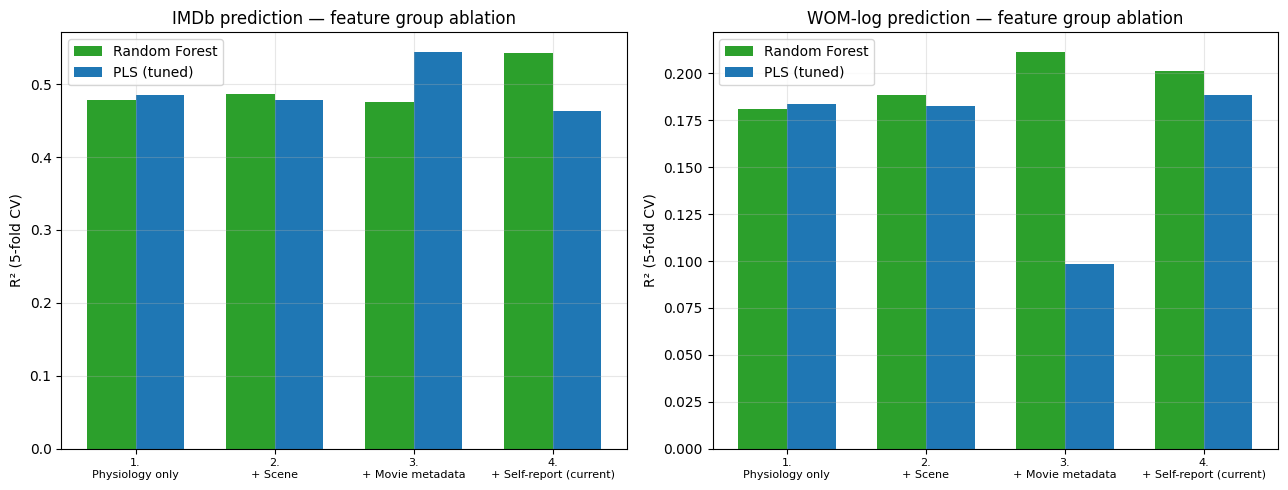

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of R² across configs
configs_short = list(results.keys())
labels = [c.replace('. ', '.\n') for c in configs_short]

# IMDb R²
rf_imdb_r2  = [results[c]['RF_imdb']['r2'] for c in configs_short]
pls_imdb_r2 = [results[c]['PLS_imdb_tuned']['r2'] for c in configs_short]

x = np.arange(len(configs_short))
w = 0.35
axes[0].bar(x - w/2, rf_imdb_r2, w, label='Random Forest', color='#2ca02c')
axes[0].bar(x + w/2, pls_imdb_r2, w, label='PLS (tuned)', color='#1f77b4')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('R² (5-fold CV)')
axes[0].set_title('IMDb prediction — feature group ablation')
axes[0].legend()
axes[0].grid(alpha=0.3)

# WOM R²
rf_wom_r2  = [results[c]['RF_wom']['r2'] for c in configs_short]
pls_wom_r2 = [results[c]['PLS_wom_tuned']['r2'] for c in configs_short]
axes[1].bar(x - w/2, rf_wom_r2, w, label='Random Forest', color='#2ca02c')
axes[1].bar(x + w/2, pls_wom_r2, w, label='PLS (tuned)', color='#1f77b4')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel('R² (5-fold CV)')
axes[1].set_title('WOM-log prediction — feature group ablation')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()